<a href="https://colab.research.google.com/github/Sanjana30789/RL_MINI_PROJEECT/blob/master/RL_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries (most are pre-installed in Colab)
!pip install -q gymnasium torch torchvision matplotlib numpy pandas seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
print('✅ All libraries loaded successfully!')

✅ Using device: cpu
✅ All libraries loaded successfully!


In [2]:
class LearningEnvironment:
    """
    Simulated student learning environment for RL-based recommendation.

    State:   Student knowledge vector across N_TOPICS topics (each 0-4)
    Action:  Index of content item to recommend (0 to N_CONTENT-1)
    Reward:  Based on match between content difficulty and student level
    """

    TOPICS = ['Math', 'Science', 'English', 'History', 'Coding']
    N_TOPICS = 5
    N_LEVELS = 5       # 0 to 4
    N_CONTENT = 20     # Total content items in library
    MAX_STEPS = 50     # Steps per episode

    def __init__(self):
        # Content library: each item has (topic_id, difficulty)
        # 4 items per topic, difficulties 0-4
        self.content_library = []
        for topic in range(self.N_TOPICS):
            for diff in range(4):
                self.content_library.append({
                    'id': len(self.content_library),
                    'topic': topic,
                    'topic_name': self.TOPICS[topic],
                    'difficulty': diff,
                    'name': f'{self.TOPICS[topic]} Level {diff+1}'
                })

        self.state = None
        self.step_count = 0
        self.reset()

    def reset(self):
        """Reset student to random initial knowledge levels."""
        self.state = np.random.randint(0, 3, size=self.N_TOPICS)  # Random beginner levels
        self.step_count = 0
        return self.state.copy()

    def step(self, action):
        """
        Take action (recommend content item).
        Returns: (next_state, reward, done, info)
        """
        content = self.content_library[action]
        topic = content['topic']
        difficulty = content['difficulty']
        student_level = self.state[topic]

        # Reward logic
        level_diff = difficulty - student_level

        if level_diff == 0:
            reward = 10.0     # Perfect match!
            # Student has 60% chance to improve
            if np.random.random() < 0.6:
                self.state[topic] = min(self.state[topic] + 1, self.N_LEVELS - 1)
        elif level_diff == 1:
            reward = 5.0      # Slightly challenging - good stretch
            if np.random.random() < 0.3:
                self.state[topic] = min(self.state[topic] + 1, self.N_LEVELS - 1)
        elif level_diff > 1:
            reward = -5.0     # Too hard - frustrating
        elif level_diff == -1:
            reward = 2.0      # Slightly easy - ok for review
        else:
            reward = -2.0     # Too easy - boring

        # Bonus for mastering a topic
        if self.state[topic] == self.N_LEVELS - 1:
            reward += 15.0

        self.step_count += 1
        done = self.step_count >= self.MAX_STEPS

        info = {
            'topic': content['topic_name'],
            'difficulty': difficulty,
            'student_level': student_level,
            'content_name': content['name']
        }

        return self.state.copy(), reward, done, info

    def state_to_index(self, state):
        """Convert state vector to single integer index (for tabular methods)."""
        index = 0
        for i, s in enumerate(state):
            index += int(s) * (self.N_LEVELS ** i)
        return index

    @property
    def state_size(self):
        return self.N_TOPICS  # For DQN

    @property
    def action_size(self):
        return self.N_CONTENT

    @property
    def n_states(self):
        return self.N_LEVELS ** self.N_TOPICS  # For tabular methods


# Test the environment
env = LearningEnvironment()
state = env.reset()
print('📚 Content Library (first 8 items):')
for item in env.content_library[:8]:
    print(f"  [{item['id']:2d}] {item['name']} (topic={item['topic_name']}, difficulty={item['difficulty']})")

print(f'\n🎓 Initial Student State: {dict(zip(env.TOPICS, state))}')
print(f'📊 State Space Size: {env.n_states}')
print(f'🎯 Action Space Size: {env.action_size}')

📚 Content Library (first 8 items):
  [ 0] Math Level 1 (topic=Math, difficulty=0)
  [ 1] Math Level 2 (topic=Math, difficulty=1)
  [ 2] Math Level 3 (topic=Math, difficulty=2)
  [ 3] Math Level 4 (topic=Math, difficulty=3)
  [ 4] Science Level 1 (topic=Science, difficulty=0)
  [ 5] Science Level 2 (topic=Science, difficulty=1)
  [ 6] Science Level 3 (topic=Science, difficulty=2)
  [ 7] Science Level 4 (topic=Science, difficulty=3)

🎓 Initial Student State: {'Math': np.int64(0), 'Science': np.int64(2), 'English': np.int64(1), 'History': np.int64(2), 'Coding': np.int64(2)}
📊 State Space Size: 3125
🎯 Action Space Size: 20


In [3]:
class QLearningAgent:
    """
    Tabular Q-Learning agent for content recommendation.

    Q-table: [state_index x action] -> expected cumulative reward
    Update: Q(s,a) += alpha * [r + gamma * max Q(s',a') - Q(s,a)]
    """

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha          # Learning rate
        self.gamma = gamma          # Discount factor
        self.epsilon = epsilon      # Exploration rate
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Initialize Q-table with small random values
        self.q_table = np.zeros((n_states, n_actions))

    def select_action(self, state_idx):
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)  # Explore
        return np.argmax(self.q_table[state_idx])      # Exploit

    def update(self, state_idx, action, reward, next_state_idx, done):
        """Q-Learning update rule (off-policy)."""
        current_q = self.q_table[state_idx, action]

        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_table[next_state_idx])

        # TD Update
        self.q_table[state_idx, action] += self.alpha * (target_q - current_q)

        # Decay exploration
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def best_recommendation(self, state_idx):
        """Return best action for a given state."""
        return np.argmax(self.q_table[state_idx])


def train_q_learning(n_episodes=500):
    env = LearningEnvironment()
    agent = QLearningAgent(
        n_states=env.n_states,
        n_actions=env.action_size,
        alpha=0.1, gamma=0.95,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995
    )

    rewards_per_episode = []
    epsilon_history = []

    for episode in range(n_episodes):
        state = env.reset()
        state_idx = env.state_to_index(state)
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state_idx)
            next_state, reward, done, _ = env.step(action)
            next_state_idx = env.state_to_index(next_state)

            agent.update(state_idx, action, reward, next_state_idx, done)

            state_idx = next_state_idx
            total_reward += reward

        rewards_per_episode.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if (episode + 1) % 100 == 0:
            avg = np.mean(rewards_per_episode[-100:])
            print(f'  Episode {episode+1:4d} | Avg Reward: {avg:7.2f} | ε: {agent.epsilon:.3f}')

    return agent, rewards_per_episode, epsilon_history


print('🚀 Training Q-Learning Agent...')
q_agent, q_rewards, q_epsilon = train_q_learning(n_episodes=500)
print(f'\n✅ Q-Learning Training Complete!')
print(f'   Final Avg Reward (last 100 eps): {np.mean(q_rewards[-100:]):.2f}')

🚀 Training Q-Learning Agent...
  Episode  100 | Avg Reward:  112.60 | ε: 0.050
  Episode  200 | Avg Reward:  116.60 | ε: 0.050
  Episode  300 | Avg Reward:  114.31 | ε: 0.050
  Episode  400 | Avg Reward:  118.49 | ε: 0.050
  Episode  500 | Avg Reward:  119.60 | ε: 0.050

✅ Q-Learning Training Complete!
   Final Avg Reward (last 100 eps): 119.60


In [4]:
class SARSAAgent:
    """
    SARSA (On-policy TD) agent for content recommendation.

    Key difference from Q-Learning: uses Q(s', a') where a' is the
    ACTUAL next action chosen by the policy (not the greedy max).
    """

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.q_table = np.zeros((n_states, n_actions))

    def select_action(self, state_idx):
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.q_table[state_idx])

    def update(self, state_idx, action, reward, next_state_idx, next_action, done):
        """SARSA update rule (on-policy) — uses next_action, not max."""
        current_q = self.q_table[state_idx, action]

        if done:
            target_q = reward
        else:
            # KEY DIFFERENCE: uses Q(s', a') not max Q(s', *)
            target_q = reward + self.gamma * self.q_table[next_state_idx, next_action]

        self.q_table[state_idx, action] += self.alpha * (target_q - current_q)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


def train_sarsa(n_episodes=500):
    env = LearningEnvironment()
    agent = SARSAAgent(
        n_states=env.n_states,
        n_actions=env.action_size,
        alpha=0.1, gamma=0.95,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995
    )

    rewards_per_episode = []

    for episode in range(n_episodes):
        state = env.reset()
        state_idx = env.state_to_index(state)
        action = agent.select_action(state_idx)
        total_reward = 0
        done = False

        while not done:
            next_state, reward, done, _ = env.step(action)
            next_state_idx = env.state_to_index(next_state)
            next_action = agent.select_action(next_state_idx)  # On-policy: choose next action NOW

            agent.update(state_idx, action, reward, next_state_idx, next_action, done)

            state_idx = next_state_idx
            action = next_action  # Use the same action we chose for update
            total_reward += reward

        rewards_per_episode.append(total_reward)

        if (episode + 1) % 100 == 0:
            avg = np.mean(rewards_per_episode[-100:])
            print(f'  Episode {episode+1:4d} | Avg Reward: {avg:7.2f} | ε: {agent.epsilon:.3f}')

    return agent, rewards_per_episode


print('🚀 Training SARSA Agent...')
sarsa_agent, sarsa_rewards = train_sarsa(n_episodes=500)
print(f'\n✅ SARSA Training Complete!')
print(f'   Final Avg Reward (last 100 eps): {np.mean(sarsa_rewards[-100:]):.2f}')

🚀 Training SARSA Agent...
  Episode  100 | Avg Reward:  117.87 | ε: 0.050
  Episode  200 | Avg Reward:  112.95 | ε: 0.050
  Episode  300 | Avg Reward:  110.82 | ε: 0.050
  Episode  400 | Avg Reward:  117.04 | ε: 0.050
  Episode  500 | Avg Reward:  131.67 | ε: 0.050

✅ SARSA Training Complete!
   Final Avg Reward (last 100 eps): 131.67


In [5]:
# ---- Neural Network Architecture ----
class DQNNetwork(nn.Module):
    """
    Deep Q-Network: maps state -> Q-values for all actions.
    Input:  student knowledge vector (N_TOPICS = 5 features)
    Output: Q-value for each content item (N_CONTENT = 20)
    """

    def __init__(self, state_size, action_size):
        super(DQNNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, action_size)

        # Xavier initialization for stable training
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)
        nn.init.xavier_uniform_(self.fc4.weight)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)  # Raw Q-values (no activation)


# ---- Experience Replay Buffer ----
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    """Stores past (s, a, r, s', done) transitions for random sampling."""

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)


# ---- DQN Agent ----
class DQNAgent:
    """
    DQN Agent with:
    - Online network (updated every step)
    - Target network (updated every C steps)
    - Experience Replay
    - ε-greedy exploration
    """

    def __init__(self, state_size, action_size,
                 lr=1e-3, gamma=0.95, batch_size=64,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                 target_update_freq=10, buffer_size=10000):

        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.target_update_freq = target_update_freq
        self.update_count = 0

        # Online and Target networks
        self.online_net = DQNNetwork(state_size, action_size).to(device)
        self.target_net = DQNNetwork(state_size, action_size).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()  # Target net never in training mode

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.losses = []

    def select_action(self, state):
        """ε-greedy with neural network."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_size)

        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.online_net(state_tensor)
        return q_values.argmax().item()

    def remember(self, state, action, reward, next_state, done):
        """Store transition in replay buffer."""
        self.memory.push(state, action, reward, next_state, done)

    def learn(self):
        """Sample batch and update online network."""
        if len(self.memory) < self.batch_size:
            return

        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        states = torch.FloatTensor(np.array(batch.state)).to(device)
        actions = torch.LongTensor(batch.action).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(batch.reward).to(device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(device)
        dones = torch.FloatTensor(batch.done).to(device)

        # Current Q values from online network
        current_q = self.online_net(states).gather(1, actions).squeeze()

        # Target Q values from target network (no gradient)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)

        # Huber loss (more robust than MSE)
        loss = F.smooth_l1_loss(current_q, target_q)
        self.losses.append(loss.item())

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), 1.0)
        self.optimizer.step()

        # Epsilon decay
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        # Periodically sync target network
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())


def train_dqn(n_episodes=500):
    env = LearningEnvironment()
    agent = DQNAgent(
        state_size=env.state_size,
        action_size=env.action_size,
        lr=1e-3, gamma=0.95, batch_size=64,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995,
        target_update_freq=10
    )

    rewards_per_episode = []

    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done, _ = env.step(action)

            agent.remember(state, action, reward, next_state, done)
            agent.learn()

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

        if (episode + 1) % 100 == 0:
            avg = np.mean(rewards_per_episode[-100:])
            print(f'  Episode {episode+1:4d} | Avg Reward: {avg:7.2f} | ε: {agent.epsilon:.3f} | Loss: {np.mean(agent.losses[-100:]) if agent.losses else 0:.4f}')

    return agent, rewards_per_episode


print('🚀 Training DQN Agent...')
dqn_agent, dqn_rewards = train_dqn(n_episodes=500)
print(f'\n✅ DQN Training Complete!')
print(f'   Final Avg Reward (last 100 eps): {np.mean(dqn_rewards[-100:]):.2f}')

🚀 Training DQN Agent...
  Episode  100 | Avg Reward:  636.32 | ε: 0.050 | Loss: 11.6203
  Episode  200 | Avg Reward:  697.83 | ε: 0.050 | Loss: 12.5719
  Episode  300 | Avg Reward:  702.67 | ε: 0.050 | Loss: 10.0177
  Episode  400 | Avg Reward:  732.37 | ε: 0.050 | Loss: 9.3966
  Episode  500 | Avg Reward:  730.86 | ε: 0.050 | Loss: 8.1463

✅ DQN Training Complete!
   Final Avg Reward (last 100 eps): 730.86


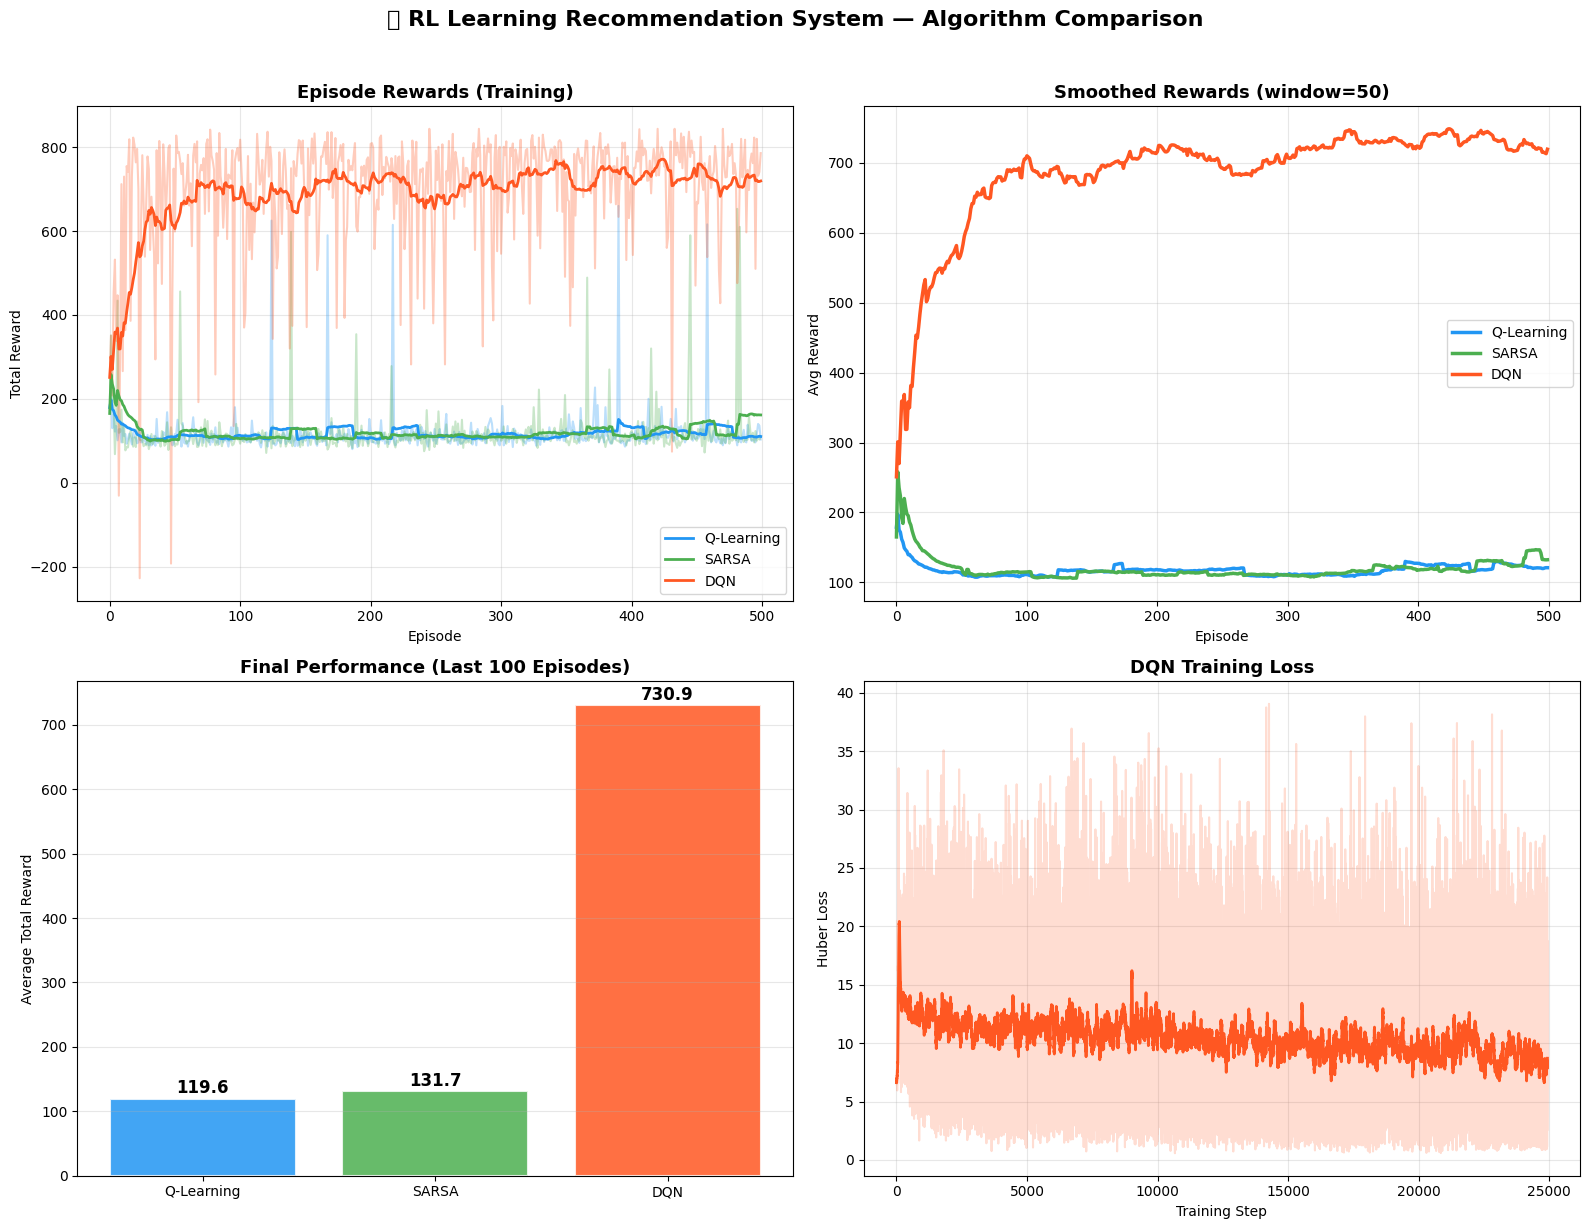

✅ Plot saved as rl_comparison.png


In [6]:
def smooth(data, window=20):
    """Moving average smoothing for cleaner plots."""
    return pd.Series(data).rolling(window, min_periods=1).mean().values


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🎓 RL Learning Recommendation System — Algorithm Comparison',
             fontsize=16, fontweight='bold', y=1.02)

colors = {'Q-Learning': '#2196F3', 'SARSA': '#4CAF50', 'DQN': '#FF5722'}

# --- Plot 1: Raw Rewards ---
ax1 = axes[0, 0]
ax1.plot(q_rewards, alpha=0.3, color=colors['Q-Learning'])
ax1.plot(sarsa_rewards, alpha=0.3, color=colors['SARSA'])
ax1.plot(dqn_rewards, alpha=0.3, color=colors['DQN'])
ax1.plot(smooth(q_rewards), color=colors['Q-Learning'], linewidth=2, label='Q-Learning')
ax1.plot(smooth(sarsa_rewards), color=colors['SARSA'], linewidth=2, label='SARSA')
ax1.plot(smooth(dqn_rewards), color=colors['DQN'], linewidth=2, label='DQN')
ax1.set_title('Episode Rewards (Training)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Running Average (window=50) ---
ax2 = axes[0, 1]
window = 50
ax2.plot(smooth(q_rewards, window), color=colors['Q-Learning'], linewidth=2.5, label='Q-Learning')
ax2.plot(smooth(sarsa_rewards, window), color=colors['SARSA'], linewidth=2.5, label='SARSA')
ax2.plot(smooth(dqn_rewards, window), color=colors['DQN'], linewidth=2.5, label='DQN')
ax2.set_title(f'Smoothed Rewards (window={window})', fontsize=13, fontweight='bold')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Avg Reward')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Bar chart comparison ---
ax3 = axes[1, 0]
algorithms = ['Q-Learning', 'SARSA', 'DQN']
final_avgs = [
    np.mean(q_rewards[-100:]),
    np.mean(sarsa_rewards[-100:]),
    np.mean(dqn_rewards[-100:])
]
bars = ax3.bar(algorithms, final_avgs, color=[colors[a] for a in algorithms],
               edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, final_avgs):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax3.set_title('Final Performance (Last 100 Episodes)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Average Total Reward')
ax3.grid(True, alpha=0.3, axis='y')

# --- Plot 4: DQN Loss ---
ax4 = axes[1, 1]
if dqn_agent.losses:
    loss_smooth = smooth(dqn_agent.losses, 50)
    ax4.plot(dqn_agent.losses, alpha=0.2, color=colors['DQN'])
    ax4.plot(loss_smooth, color=colors['DQN'], linewidth=2)
    ax4.set_title('DQN Training Loss', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Training Step')
    ax4.set_ylabel('Huber Loss')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as rl_comparison.png')

In [7]:
def run_demo(agent, agent_name, n_steps=10):
    """
    Visualize the agent making recommendations to a student.
    Shows state evolution and reward at each step.
    """
    env = LearningEnvironment()
    state = env.reset()

    print(f'\n{"="*60}')
    print(f'🤖 {agent_name} — Live Recommendation Demo')
    print(f'{"="*60}')
    print(f'Initial Student Levels: {dict(zip(env.TOPICS, state))}')
    print(f'{"─"*60}')

    total_reward = 0
    state_history = [state.copy()]

    for step in range(n_steps):
        # Select action
        if agent_name == 'DQN':
            action = agent.select_action(state)
        else:
            state_idx = env.state_to_index(state)
            action = np.argmax(agent.q_table[state_idx])

        next_state, reward, done, info = env.step(action)
        total_reward += reward

        match = '✅ Perfect!' if reward == 10 else ('🔥 Mastered!' if reward > 10 else ('⚠️ Too hard' if reward < 0 else '👍 Good'))
        print(f'Step {step+1:2d} | Recommend: {info["content_name"]:20s} | '
              f'Student Lvl: {info["student_level"]} → Content Diff: {info["difficulty"]} | '
              f'Reward: {reward:+6.1f} {match}')

        state = next_state
        state_history.append(state.copy())
        if done:
            break

    print(f'{"─"*60}')
    print(f'Final Student Levels: {dict(zip(env.TOPICS, state))}')
    print(f'Total Reward: {total_reward:.1f}')

    return state_history


# Run demos for all 3 agents
# Set epsilon to 0 for pure exploitation during demo
q_agent.epsilon = 0
sarsa_agent.epsilon = 0
dqn_agent.epsilon = 0

q_hist = run_demo(q_agent, 'Q-Learning')
s_hist = run_demo(sarsa_agent, 'SARSA')
d_hist = run_demo(dqn_agent, 'DQN')


🤖 Q-Learning — Live Recommendation Demo
Initial Student Levels: {'Math': np.int64(2), 'Science': np.int64(1), 'English': np.int64(1), 'History': np.int64(2), 'Coding': np.int64(1)}
────────────────────────────────────────────────────────────
Step  1 | Recommend: Math Level 2         | Student Lvl: 2 → Content Diff: 1 | Reward:   +2.0 👍 Good
Step  2 | Recommend: Math Level 2         | Student Lvl: 2 → Content Diff: 1 | Reward:   +2.0 👍 Good
Step  3 | Recommend: Math Level 2         | Student Lvl: 2 → Content Diff: 1 | Reward:   +2.0 👍 Good
Step  4 | Recommend: Math Level 2         | Student Lvl: 2 → Content Diff: 1 | Reward:   +2.0 👍 Good
Step  5 | Recommend: Math Level 2         | Student Lvl: 2 → Content Diff: 1 | Reward:   +2.0 👍 Good
Step  6 | Recommend: Math Level 2         | Student Lvl: 2 → Content Diff: 1 | Reward:   +2.0 👍 Good
Step  7 | Recommend: Math Level 2         | Student Lvl: 2 → Content Diff: 1 | Reward:   +2.0 👍 Good
Step  8 | Recommend: Math Level 2         | Studen

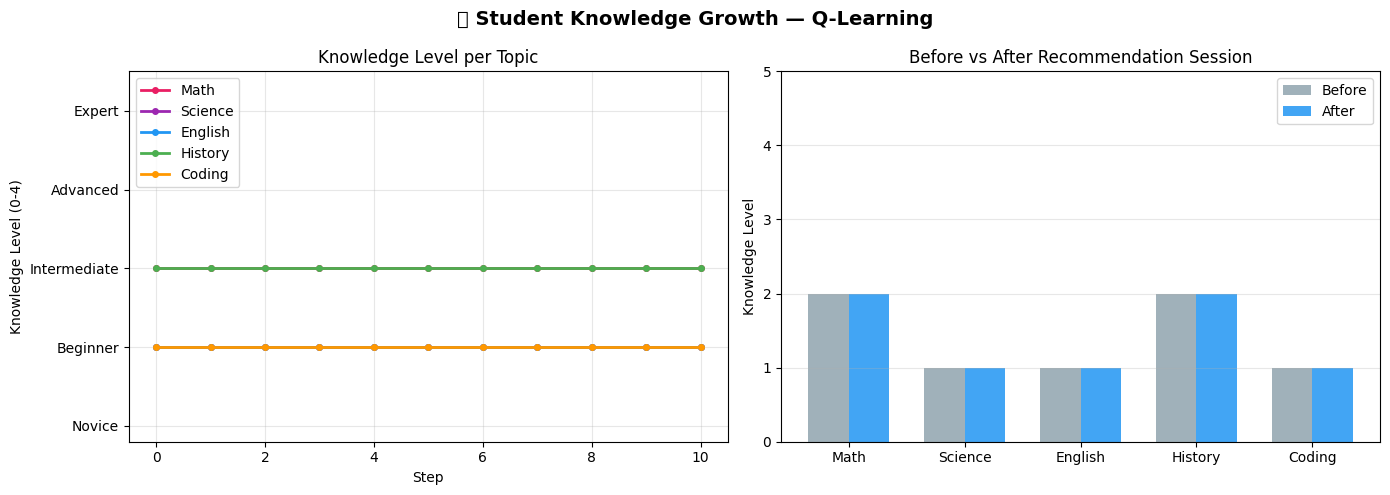

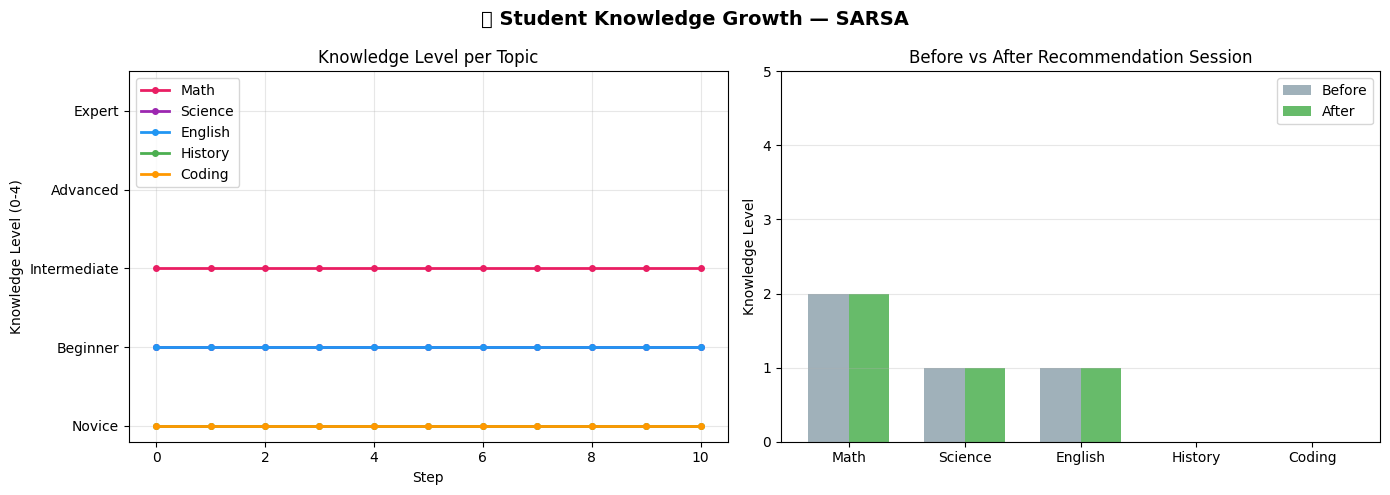

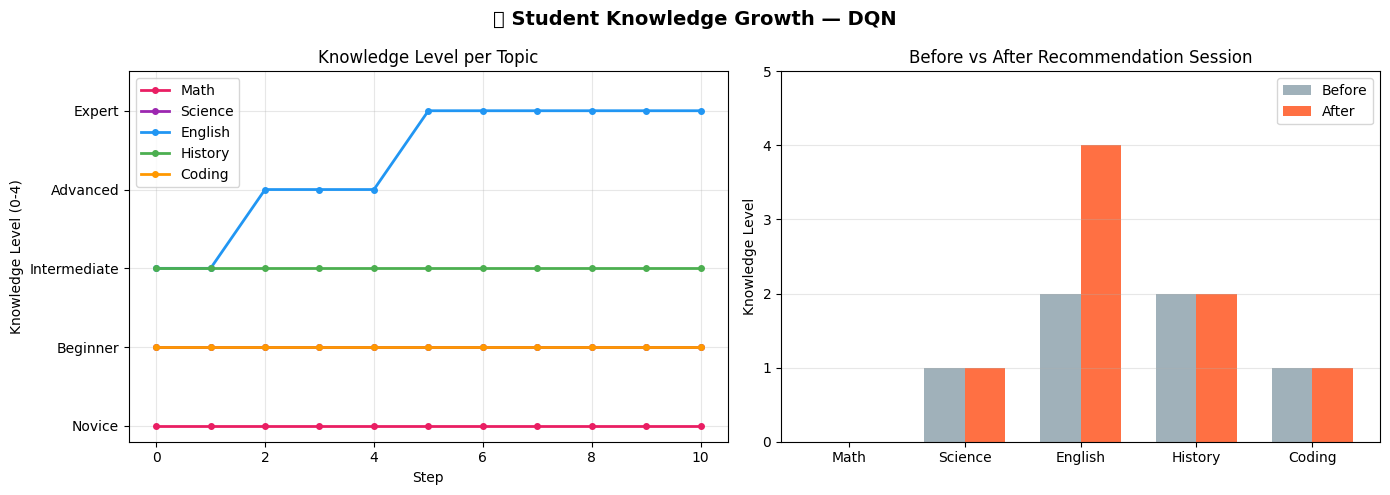

In [8]:
def plot_knowledge_growth(history, title, color):
    """Plot how student knowledge grows over steps."""
    history = np.array(history)
    topics = LearningEnvironment.TOPICS

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'📈 Student Knowledge Growth — {title}', fontsize=14, fontweight='bold')

    # Line plot
    topic_colors = ['#E91E63', '#9C27B0', '#2196F3', '#4CAF50', '#FF9800']
    for i, (topic, tc) in enumerate(zip(topics, topic_colors)):
        ax1.plot(history[:, i], marker='o', markersize=4, label=topic, color=tc, linewidth=2)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Knowledge Level (0-4)')
    ax1.set_ylim(-0.2, 4.5)
    ax1.set_yticks(range(5))
    ax1.set_yticklabels(['Novice', 'Beginner', 'Intermediate', 'Advanced', 'Expert'])
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Knowledge Level per Topic')

    # Before/After bar chart
    x = np.arange(len(topics))
    w = 0.35
    ax2.bar(x - w/2, history[0], w, label='Before', color='#90A4AE', alpha=0.85)
    ax2.bar(x + w/2, history[-1], w, label='After', color=color, alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(topics)
    ax2.set_ylabel('Knowledge Level')
    ax2.set_ylim(0, 5)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_title('Before vs After Recommendation Session')

    plt.tight_layout()
    plt.savefig(f'growth_{title.lower().replace("-","_").replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()


plot_knowledge_growth(q_hist, 'Q-Learning', '#2196F3')
plot_knowledge_growth(s_hist, 'SARSA', '#4CAF50')
plot_knowledge_growth(d_hist, 'DQN', '#FF5722')

In [9]:
print('\n' + '='*70)
print('📊 ALGORITHM COMPARISON SUMMARY')
print('='*70)

summary = pd.DataFrame({
    'Algorithm': ['Q-Learning', 'SARSA', 'DQN'],
    'Type': ['Off-policy TD', 'On-policy TD', 'Deep Off-policy'],
    'State Rep': ['Tabular (lookup)', 'Tabular (lookup)', 'Neural Network'],
    'Avg Reward (last 100)': [
        f"{np.mean(q_rewards[-100:]):.1f}",
        f"{np.mean(sarsa_rewards[-100:]):.1f}",
        f"{np.mean(dqn_rewards[-100:]):.1f}"
    ],
    'Scales to large state?': ['❌ No', '❌ No', '✅ Yes'],
    'Exploration': ['ε-greedy', 'ε-greedy', 'ε-greedy'],
    'Key Feature': ['Max Q (greedy target)', 'Uses actual next action', 'Replay + Target Net']
})

print(summary.to_string(index=False))
print('='*70)

best = np.argmax([
    np.mean(q_rewards[-100:]),
    np.mean(sarsa_rewards[-100:]),
    np.mean(dqn_rewards[-100:])
])
winner = ['Q-Learning', 'SARSA', 'DQN'][best]
print(f'\n🏆 Best Performing Algorithm: {winner}')
print('\n💡 Key Takeaways:')
print('   • Q-Learning: Fast, simple, good for small state spaces')
print('   • SARSA: Safer, conservative — accounts for exploration policy')
print('   • DQN: Scales to complex environments with continuous/large states')
print('   • For real-world use with 1000s of students: DQN or Actor-Critic methods')


📊 ALGORITHM COMPARISON SUMMARY
 Algorithm            Type        State Rep Avg Reward (last 100) Scales to large state? Exploration             Key Feature
Q-Learning   Off-policy TD Tabular (lookup)                 119.6                   ❌ No    ε-greedy   Max Q (greedy target)
     SARSA    On-policy TD Tabular (lookup)                 131.7                   ❌ No    ε-greedy Uses actual next action
       DQN Deep Off-policy   Neural Network                 730.9                  ✅ Yes    ε-greedy     Replay + Target Net

🏆 Best Performing Algorithm: DQN

💡 Key Takeaways:
   • Q-Learning: Fast, simple, good for small state spaces
   • SARSA: Safer, conservative — accounts for exploration policy
   • DQN: Scales to complex environments with continuous/large states
   • For real-world use with 1000s of students: DQN or Actor-Critic methods


In [10]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 75.1 MB/s eta 0:00:00


In [11]:
import streamlit as st
import numpy as np

# Assume you already trained agent
env = LearningEnvironment()
agent, _, _ = train_q_learning(500)
agent.epsilon = 0

st.title("🎓 Smart Learning Recommendation System")

st.subheader("📊 Set Your Knowledge Levels")

math = st.slider("Math", 0, 4, 1)
science = st.slider("Science", 0, 4, 1)
english = st.slider("English", 0, 4, 1)
history = st.slider("History", 0, 4, 1)
coding = st.slider("Coding", 0, 4, 1)

user_state = np.array([math, science, english, history, coding])

if st.button("🎯 Get Recommendation"):

    env.state = user_state.copy()

    state_idx = env.state_to_index(user_state)
    action = agent.best_recommendation(state_idx)

    next_state, reward, _, info = env.step(action)

    st.success(f"📘 Recommended: {info['content_name']}")
    st.write(f"📚 Topic: {info['topic']}")
    st.write(f"🎯 Difficulty: {info['difficulty']}")
    st.write(f"💡 Reward: {reward}")

    st.subheader("📈 Updated Knowledge")
    st.write(dict(zip(env.TOPICS, next_state)))

  Episode  100 | Avg Reward:  133.74 | ε: 0.050
  Episode  200 | Avg Reward:  143.58 | ε: 0.050
  Episode  300 | Avg Reward:  125.07 | ε: 0.050


2026-04-21 15:23:30.042 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


  Episode  400 | Avg Reward:  137.47 | ε: 0.050
  Episode  500 | Avg Reward:  129.62 | ε: 0.050


2026-04-21 15:23:30.301 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-21 15:23:30.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:23:30.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:23:30.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:23:30.316 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:23:30.318 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:23:30.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 15:23:30.330 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running 